In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Using Random Forest for better performance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
# Load dataset from previous notebook
df = pd.read_csv("C:/Users/BIT/Desktop/AIML ASSIGNMENT/data/feature_engineered_data.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (VERY IMPORTANT for forecasting)
df = df.sort_values(by='Date')

df.head()

,Date,Person_ID,Age,Gender,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled,Day,Month,Year,Day_of_Week,Rolling_Mean_3,Rolling_Std_3,Lag_1,City_Islamabad,City_Karachi,City_Lahore,City_Multan,City_Rawalpindi
0,2025-01-01,P0061,41.0,1.0,17.7,0,1.76,0.160279,1,1,2025,2,2.330000,0.538424,2.83,False,True,False,False,False
66,2025-01-01,P0044,22.0,0.0,37.1,0,2.67,0.477352,1,1,2025,2,2.923333,0.271539,2.89,True,False,False,False,False
65,2025-01-01,P0065,31.0,0.0,28.6,1,2.89,0.554007,1,1,2025,2,2.576667,0.835304,3.21,False,False,True,False,False
64,2025-01-01,P0099,60.0,1.0,38.0,1,3.21,0.665505,1,1,2025,2,2.680000,0.909340,1.63,False,False,False,False,False
63,2025-01-01,P0046,36.0,0.0,16.9,0,1.63,0.114983,1,1,2025,2,2.680000,0.909340,3.20,False,False,False,False,False


In [6]:
# Create a numerical time index
df['Time_Index'] = np.arange(len(df))

df[['Date', 'Time_Index']].head()

,Date,Time_Index
0,2025-01-01,0
66,2025-01-01,1
65,2025-01-01,2
64,2025-01-01,3
63,2025-01-01,4


In [14]:
# Feature (independent variables) - using better features
X = df[['Lag_1', 'Rolling_Mean_3', 'Rolling_Std_3', 'Temperature_C']]

# Target (dependent variable)
y = df['Water_Consumed_Liters']

In [15]:
# Split data into training and testing sets (80-20 split)
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [16]:
# Initialize model - upgraded to Random Forest
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [19]:
# Predict on test data
predictions = model.predict(X_test)

In [20]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

Mean Absolute Error (MAE): 0.18143061419098816
Mean Squared Error (MSE): 0.06633714987910169


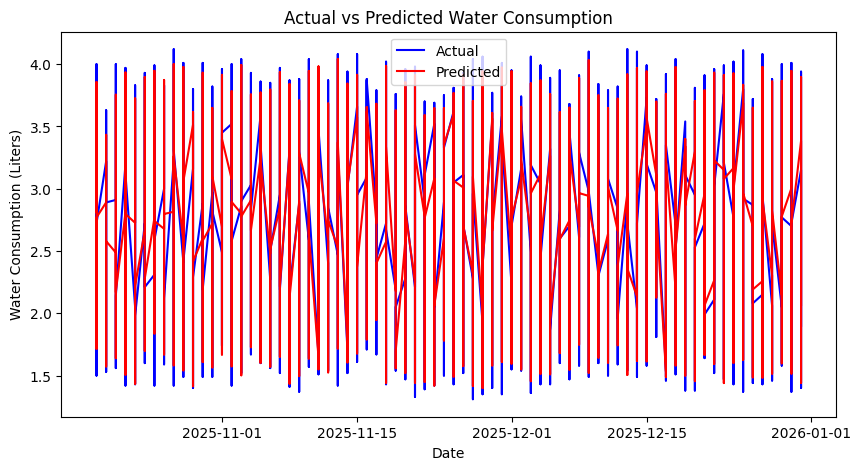

In [21]:
# Plot actual vs predicted values

plt.figure(figsize=(10,5))

plt.plot(df['Date'][train_size:], y_test, label='Actual', color='blue')
plt.plot(df['Date'][train_size:], predictions, label='Predicted', color='red')

plt.title("Actual vs Predicted Water Consumption")
plt.xlabel("Date")
plt.ylabel("Water Consumption (Liters)")
plt.legend()

plt.show()

In [18]:
# Predict future 7 days

future_days = 7
last_index = df['Time_Index'].iloc[-1]

future_index = np.arange(last_index + 1, last_index + 1 + future_days).reshape(-1, 1)

future_predictions = model.predict(future_index)

print("Future Water Consumption Predictions (next 7 days):\n")
print(future_predictions)

c:\Users\BIT\Desktop\AIML ASSIGNMENT\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but RandomForestRegressor is expecting 4 features as input.